In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
pd.options.display.max_rows = 1000
pd.options.display.max_columns = 50

In [2]:
df_customers = pd.read_csv("customers.csv")
df_loans = pd.read_csv("loans.csv")
df_bureau = pd.read_csv("bureau_data.csv")

In [3]:
df_customers.shape,df_loans.shape,df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

In [5]:
df_bureau.head(1)

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7


In [4]:
df = pd.merge(df_customers,df_loans,on = "cust_id")
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,L00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,L00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001,L00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001,L00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001,L00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [7]:
df1 = pd.merge(df,df_bureau,on = "cust_id")

In [8]:
df1.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001,L00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001,L00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001,L00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001,L00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001,L00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      50000 non-null  object 
 1   age                          50000 non-null  int64  
 2   gender                       50000 non-null  object 
 3   marital_status               50000 non-null  object 
 4   employment_status            50000 non-null  object 
 5   income                       50000 non-null  int64  
 6   number_of_dependants         50000 non-null  int64  
 7   residence_type               49938 non-null  object 
 8   years_at_current_address     50000 non-null  int64  
 9   city                         50000 non-null  object 
 10  state                        50000 non-null  object 
 11  zipcode                      50000 non-null  int64  
 12  loan_id                      50000 non-null  object 
 13  loan_purpose    

In [39]:
df1["default"] = df1["default"].astype(int)
df1.default.value_counts()

# There is presence of class imbalance

default
0    45703
1     4297
Name: count, dtype: int64

In [11]:
## To avoid data leakage, we will immeidatley split data into train test and do EDA, data cleaning, and other transformation on train.
## We willn then apply these transsformations directly to test set 

In [152]:
X = df1.drop(columns = {"default"})
y = df1["default"]

In [153]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3, random_state = 101)

In [154]:
df_train = pd.concat([X_train,y_train],axis = "columns")
df_test = pd.concat([X_test,y_test],axis = "columns")

In [155]:
df_train.shape, df_test.shape

((35000, 33), (15000, 33))

In [156]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
29671,C29672,39,M,Married,Salaried,2390000,3,Rented,9,Chennai,Tamil Nadu,600001,L29672,Home,Secured,7769000,7318000,"146,360.00",1317240,5854400,28,1372254,788206,2022-07-11,2022-07-13,2,1,32,21,125,2,54,1
48133,C48134,37,M,Single,Salaried,1527000,0,Owned,27,Lucknow,Uttar Pradesh,226001,L48134,Personal,Unsecured,1221000,1064000,"21,280.00",191520,851200,18,766079,726657,2024-05-15,2024-05-21,4,2,88,0,0,4,0,0
2872,C02873,19,M,Single,Self-Employed,938000,1,Owned,11,Chennai,Tamil Nadu,600001,L02873,Home,Secured,3860000,3547000,"70,940.00",638460,2837600,28,441560,521262,2019-11-06,2019-11-29,4,0,123,1,4,9,43,0
23899,C23900,21,F,Single,Self-Employed,886000,0,Owned,1,Pune,Maharashtra,411001,L23900,Auto,Secured,1335000,951000,"19,020.00",171180,760800,27,355723,325987,2021-12-12,2021-12-22,3,1,44,12,68,4,59,0
40469,C40470,54,M,Single,Self-Employed,2068000,0,Owned,9,Lucknow,Uttar Pradesh,226001,L40470,Home,Secured,5572000,5246000,"104,920.00",944280,4196800,34,1578665,564152,2023-08-09,2023-08-26,4,0,105,10,68,8,15,0


In [157]:
## Checking for na values

df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 46
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [158]:
df_train["residence_type"].unique()

array(['Rented', 'Owned', 'Mortgage', nan], dtype=object)

In [159]:
df_train["residence_type"].fillna(df_train["residence_type"].mode()[0],inplace = True)

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\1933222443.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train["residence_type"].fillna(df_train["residence_type"].mode()[0],inplace = True)


In [160]:
df_train["residence_type"].unique()

array(['Rented', 'Owned', 'Mortgage'], dtype=object)

In [161]:
## Now lets follow te same methodolgy for test
df_test["residence_type"].fillna(df_test["residence_type"].mode()[0],inplace = True)

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\1079247284.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["residence_type"].fillna(df_test["residence_type"].mode()[0],inplace = True)


In [162]:
## Checking for duplicates

df_train.duplicated().sum()
# No duplicaets

np.int64(0)

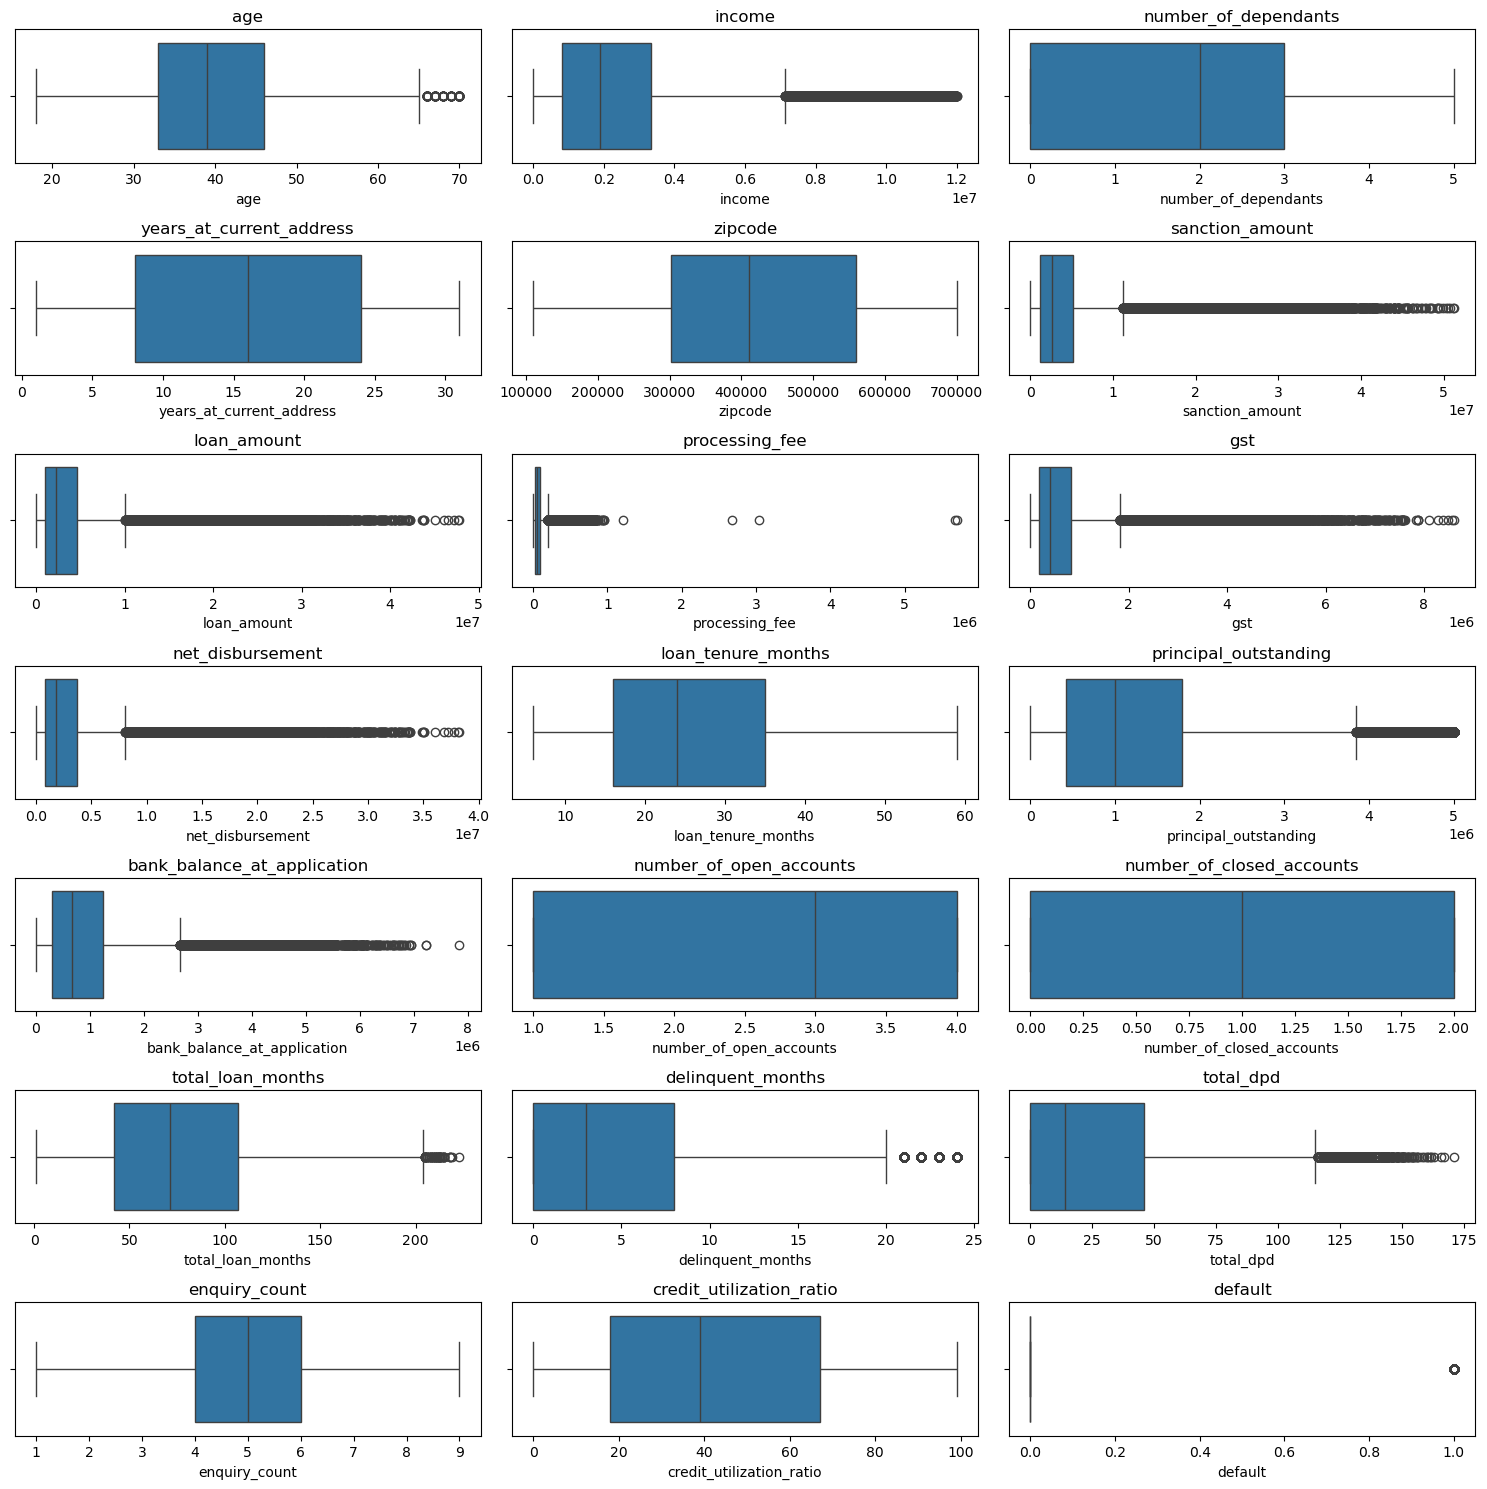

In [163]:
## Visualizing outliers


fig,axes = plt.subplots(7,3,figsize = (15,15))

columns = df_train.select_dtypes(include = [int,float]).columns

axes = axes.flatten()

for ax,col in zip(axes,columns):
    sns.boxplot(data = df_train,x = col, ax = ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [164]:
pd.options.display.float_format = '{:,.2f}'.format


In [165]:
df_train["processing_fee"].describe()

count      35,000.00
mean       80,691.67
std       117,758.93
min             0.00
25%        19,440.00
50%        44,700.00
75%        92,460.00
max     5,698,029.90
Name: processing_fee, dtype: float64

In [166]:
df_train[df_train["processing_fee"] == df_train["processing_fee"].max()]
# So here for a loan of 46 lakh, the processing fee is 56 lakh which is an error
# The proceesing fee must always be lower

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12294,C12295,49,M,Married,Salaried,3504000,2,Rented,24,Ahmedabad,Gujarat,380001,L12295,Education,Secured,5312000,4639000,"5,698,029.90",835020,3711200,25,1890831,1282049,2020-10-15,2020-10-23,1,2,58,0,0,3,86,0


In [167]:
df_train[df_train["processing_fee"] > df_train["loan_amount"]]
# So these are those error rows 

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12294,C12295,49,M,Married,Salaried,3504000,2,Rented,24,Ahmedabad,Gujarat,380001,L12295,Education,Secured,5312000,4639000,"5,698,029.90",835020,3711200,25,1890831,1282049,2020-10-15,2020-10-23,1,2,58,0,0,3,86,0
28174,C28175,36,F,Single,Self-Employed,1123000,1,Rented,31,Hyderabad,Telangana,500001,L28175,Personal,Unsecured,1025000,966000,"1,214,492.67",173880,772800,18,695519,390870,2022-05-18,2022-06-05,3,0,111,8,41,3,62,0
23981,C23982,33,F,Single,Self-Employed,1790000,0,Rented,7,Kolkata,West Bengal,700001,L23982,Auto,Secured,2649000,2234000,"2,669,791.02",402120,1787200,32,920114,511339,2021-12-15,2022-01-14,4,2,154,9,31,6,26,0
29305,C29306,52,M,Married,Self-Employed,3839000,2,Owned,11,Delhi,Delhi,110001,L29306,Personal,Unsecured,2872000,2616000,"3,036,378.01",470880,2092800,21,1883519,999324,2022-06-28,2022-07-21,2,2,42,11,65,3,2,0
33705,C33706,54,M,Married,Self-Employed,10763000,2,Mortgage,5,Ahmedabad,Gujarat,380001,L33706,Personal,Unsecured,5000000,3812000,"5,678,020.86",686160,3049600,9,2744639,4612551,2022-12-05,2022-12-30,3,1,140,0,0,5,47,0


In [168]:
df_train_1 = df_train[df_train["processing_fee"] <= df_train["loan_amount"]]

In [169]:
# Lets do the same for test
df_test = df_test[df_test["processing_fee"] <= df_test["loan_amount"]]

In [170]:
## Printing unique values of cateogrical col
cat_cols = df_train.select_dtypes(include = [object]).columns

for i in cat_cols:
    print(i,"-",df_train[i].unique())

cust_id - ['C29672' 'C48134' 'C02873' ... 'C17746' 'C17932' 'C45920']
gender - ['M' 'F']
marital_status - ['Married' 'Single']
employment_status - ['Salaried' 'Self-Employed']
residence_type - ['Rented' 'Owned' 'Mortgage']
city - ['Chennai' 'Lucknow' 'Pune' 'Ahmedabad' 'Bangalore' 'Delhi' 'Hyderabad'
 'Kolkata' 'Mumbai' 'Jaipur']
state - ['Tamil Nadu' 'Uttar Pradesh' 'Maharashtra' 'Gujarat' 'Karnataka' 'Delhi'
 'Telangana' 'West Bengal' 'Rajasthan']
loan_id - ['L29672' 'L48134' 'L02873' ... 'L17746' 'L17932' 'L45920']
loan_purpose - ['Home' 'Personal' 'Auto' 'Education' 'Personaal']
loan_type - ['Secured' 'Unsecured']
disbursal_date - ['2022-07-11' '2024-05-15' '2019-11-06' ... '2021-03-06' '2020-09-30'
 '2019-09-08']
installment_start_dt - ['2022-07-13' '2024-05-21' '2019-11-29' ... '2024-08-13' '2019-07-28'
 '2024-08-20']


In [171]:
df_train_1["loan_purpose"].replace("Personaal","Personal",inplace = True)

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\2402550441.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train_1["loan_purpose"].replace("Personaal","Personal",inplace = True)
C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\2402550441.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_1["loa

In [172]:
df_train["loan_purpose"].unique()

array(['Home', 'Personal', 'Auto', 'Education', 'Personaal'], dtype=object)

In [173]:
## Applying the same for test
df_test["loan_purpose"].replace("Personaal","Personal",inplace = True)

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\1026841252.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test["loan_purpose"].replace("Personaal","Personal",inplace = True)


In [174]:
df_train[(df_train.gst/df_train.loan_amount) >=0.2]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


## EDA

In [175]:
columns_continuous = df_train.select_dtypes(include = [int,float]).columns

In [176]:
columns_continuous

Index(['age', 'income', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

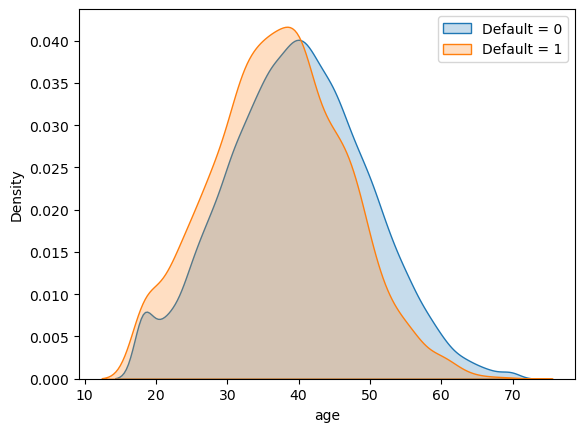

In [177]:
sns.kdeplot(df_train[df_train["default"] == 0].age,fill = True, label = "Default = 0")
sns.kdeplot(df_train[df_train["default"] == 1].age,fill = True, label = "Default = 1")
plt.legend()

Insights
1. Orange graph shifted left of graph which indicates that people with young age are more likely to default

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\2213789871.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_train_1[col][df_train_1["default"] == 0], fill = True, label = "default = 0")
C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\2213789871.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_train_1[col][df_train_1["default"] == 1], fill = True, label = "default = 1")


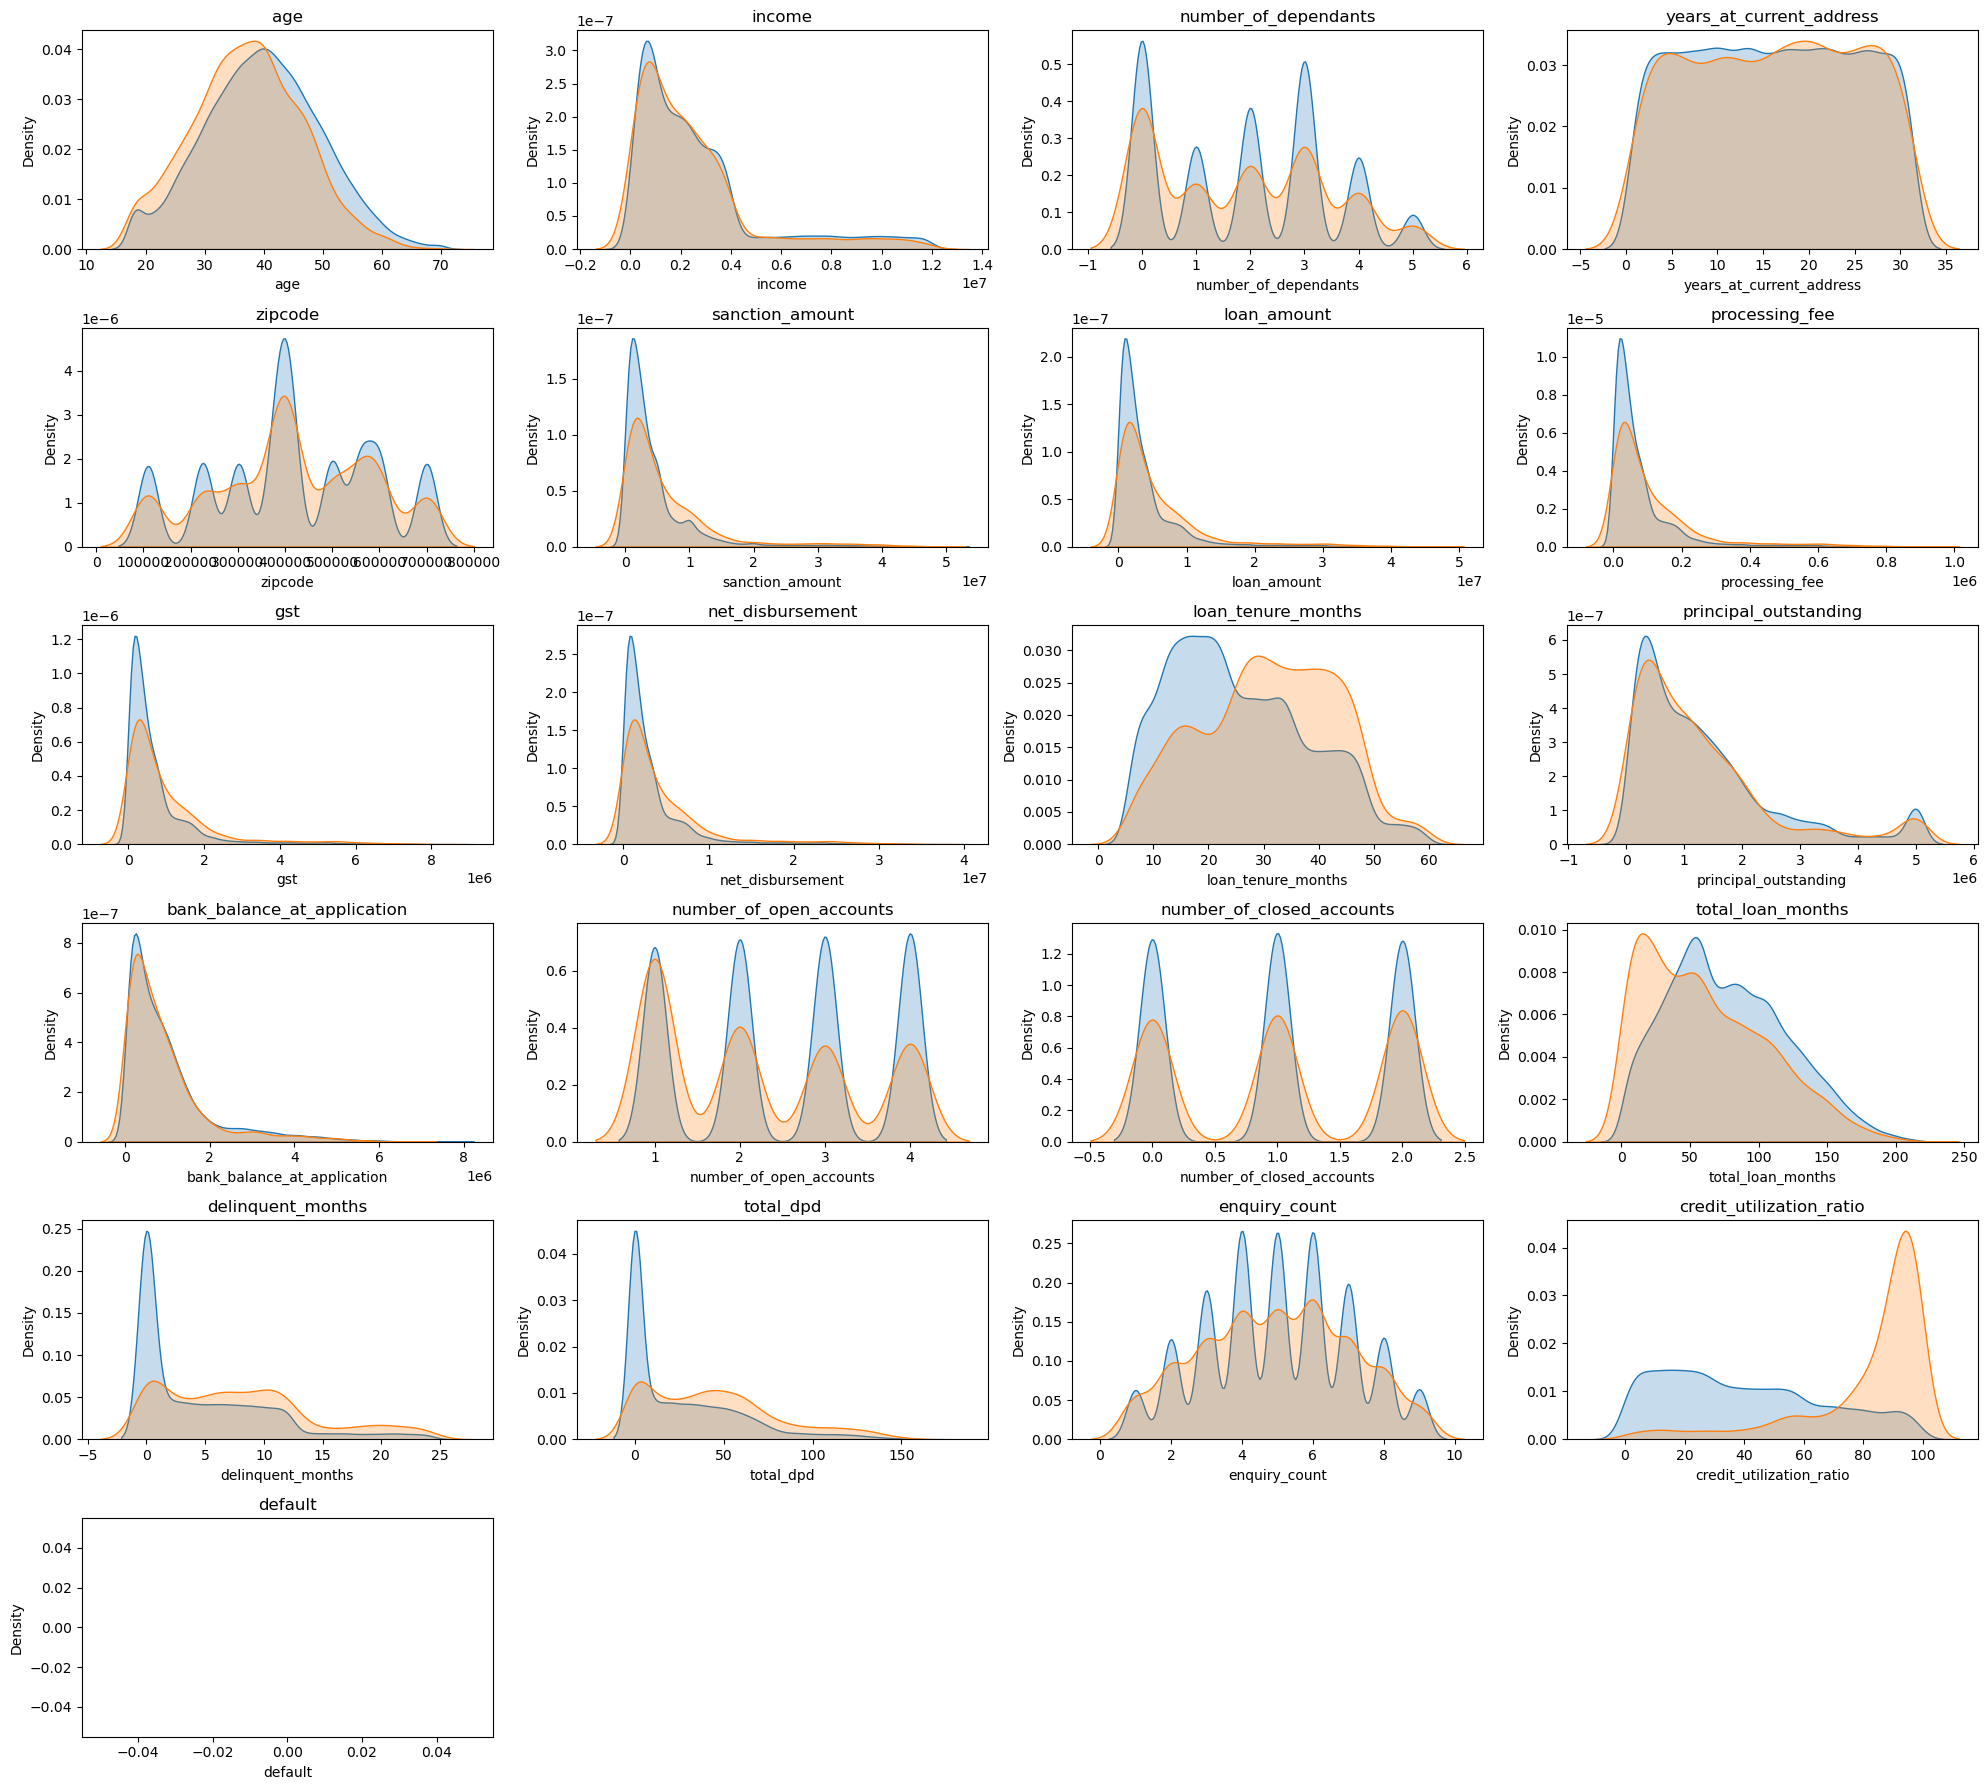

In [178]:
## Lets do the same for all numerucal columns
plt.figure(figsize = (20,18))

for i, col in enumerate(columns_continuous):
    plt.subplot(6,4,i+1)
    sns.kdeplot(df_train_1[col][df_train_1["default"] == 0], fill = True, label = "default = 0")
    sns.kdeplot(df_train_1[col][df_train_1["default"] == 1], fill = True, label = "default = 1")
    plt.title(col)

plt.tight_layout()
plt.show()

In [179]:
df_train.corr(numeric_only = True)["default"]

age                           -0.08
income                        -0.02
number_of_dependants          -0.01
years_at_current_address       0.00
zipcode                       -0.00
sanction_amount                0.08
loan_amount                    0.09
processing_fee                 0.08
gst                            0.09
net_disbursement               0.09
loan_tenure_months             0.12
principal_outstanding         -0.01
bank_balance_at_application   -0.02
number_of_open_accounts       -0.08
number_of_closed_accounts      0.01
total_loan_months             -0.10
delinquent_months              0.16
total_dpd                      0.17
enquiry_count                 -0.01
credit_utilization_ratio       0.40
default                        1.00
Name: default, dtype: float64

## Feature Engineering

In [180]:
## Creating LTI - Loan to income ratio

df_train_1["Loan_to_income"] = np.where(df_train_1["income"] != 0, 
                                        df_train_1["loan_amount"]/df_train_1["income"],
                                        0)
df_train_1

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\469081695.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_1["Loan_to_income"] = np.where(df_train_1["income"] != 0,


,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,Loan_to_income
29671,C29672,39,M,Married,Salaried,2390000,3,Rented,9,Chennai,Tamil Nadu,600001,L29672,Home,Secured,7769000,7318000,"146,360.00",1317240,5854400,28,1372254,788206,2022-07-11,2022-07-13,2,1,32,21,125,2,54,1,3.06
48133,C48134,37,M,Single,Salaried,1527000,0,Owned,27,Lucknow,Uttar Pradesh,226001,L48134,Personal,Unsecured,1221000,1064000,"21,280.00",191520,851200,18,766079,726657,2024-05-15,2024-05-21,4,2,88,0,0,4,0,0,0.70
2872,C02873,19,M,Single,Self-Employed,938000,1,Owned,11,Chennai,Tamil Nadu,600001,L02873,Home,Secured,3860000,3547000,"70,940.00",638460,2837600,28,441560,521262,2019-11-06,2019-11-29,4,0,123,1,4,9,43,0,3.78
23899,C23900,21,F,Single,Self-Employed,886000,0,Owned,1,Pune,Maharashtra,411001,L23900,Auto,Secured,1335000,951000,"19,020.00",171180,760800,27,355723,325987,2021-12-12,2021-12-22,3,1,44,12,68,4,59,0,1.07
40469,C40470,54,M,Single,Self-Employed,2068000,0,Owned,9,Lucknow,Uttar Pradesh,226001,L40470,Home,Secured,5572000,5246000,"104,920.00",944280,4196800,34,1578665,564152,2023-08-09,2023-08-26,4,0,105,10,68,8,15,0,2.54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,C05696,45,F,Married,Salaried,190000,3,Rented,29,Ahmedabad,Gujarat,380001,L05696,Home,Secured,654000,569000,"11,380.00",102420,455200,44,144351,79882,2020-02-17,2020-02-21,3,2,143,9,55,3,10,0,2.99
8006,C08007,41,F,Single,Self-Employed,9026000,0,Mortgage,5,Ahmedabad,Gujarat,380001,L08007,Personal,Unsecured,5000000,3985000,"79,700.00",717300,3188000,9,2869199,3121690,2020-05-11,2020-06-01,4,0,138,0,0,5,5,0,0.44
17745,C17746,29,M,Married,Self-Employed,3452000,4,Owned,30,Bangalore,Karnataka,560001,L17746,Personal,Unsecured,3277000,2511000,"50,220.00",451980,2008800,19,1753252,1210698,2021-05-02,2021-05-12,3,1,59,0,0,3,79,0,0.73
17931,C17932,39,M,Married,Self-Employed,1886000,2,Owned,27,Chennai,Tamil Nadu,600001,L17932,Home,Secured,6175000,4780000,"95,600.00",860400,3824000,27,1104679,724213,2021-05-09,2021-06-05,4,0,98,0,0,8,17,0,2.53


In [181]:
# Doing the same for test
df_test["Loan_to_income"] = np.where(df_test["income"] != 0, 
                                        df_test["loan_amount"]/df_test["income"],
                                        0)

In [182]:
df_train_1["Loan_to_income"].describe()

count   34,995.00
mean         1.56
std          0.97
min          0.00
25%          0.77
50%          1.16
75%          2.46
max          4.59
Name: Loan_to_income, dtype: float64

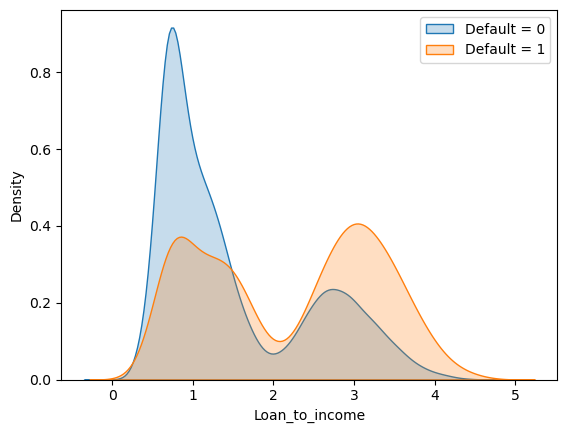

In [184]:
sns.kdeplot(df_train_1[df_train_1["default"] == 0].Loan_to_income,fill = True, label = "Default = 0")
sns.kdeplot(df_train_1[df_train_1["default"] == 1].Loan_to_income,fill = True, label = "Default = 1")
plt.legend()

## So its clear tbaht lower the loan to income ratio, lower is the chance of default

In [185]:
## We should also calculate delinquent months to loan months ratio
df_train_1["deliquent_to_loan_months"] = 100*df_train_1["delinquent_months"]/df_train_1["total_loan_months"]

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\1385517827.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_1["deliquent_to_loan_months"] = 100*df_train_1["delinquent_months"]/df_train_1["total_loan_months"]


In [186]:
df_train_1["deliquent_to_loan_months"].describe()

count   34,995.00
mean        10.36
std         17.23
min          0.00
25%          0.00
50%          3.80
75%         13.01
max        100.00
Name: deliquent_to_loan_months, dtype: float64

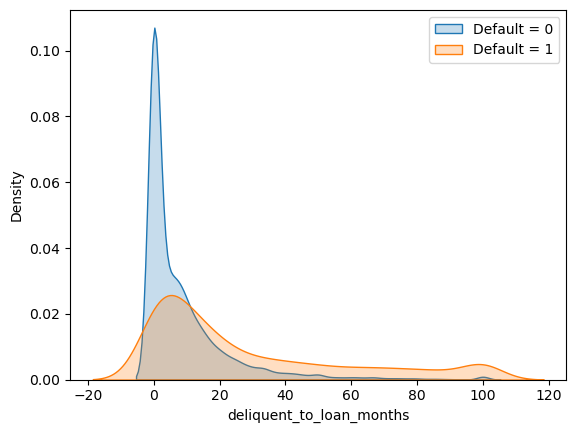

In [187]:
sns.kdeplot(df_train_1[df_train_1["default"] == 0].deliquent_to_loan_months,fill = True, label = "Default = 0")
sns.kdeplot(df_train_1[df_train_1["default"] == 1].deliquent_to_loan_months,fill = True, label = "Default = 1")
plt.legend()

# Very clearly visible that lower this value, lowe ris the chacne of defualt and vice versa

In [188]:
# Doing the same for test
df_test["deliquent_to_loan_months"] = 100*df_test["delinquent_months"]/df_test["total_loan_months"]

In [189]:
## 3. Finding average DPD per deliqeunt months

df_train_1["avg_dpd_per_delinquency"] = np.where(df_train_1["delinquent_months"] != 0, 
                                                 df_train_1["total_dpd"]/df_train_1["delinquent_months"],0)
df_train_1["avg_dpd_per_delinquency"].describe()

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\499945606.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_1["avg_dpd_per_delinquency"] = np.where(df_train_1["delinquent_months"] != 0,


count   34,995.00
mean         3.30
std          2.90
min          0.00
25%          0.00
50%          4.33
75%          5.75
max         10.00
Name: avg_dpd_per_delinquency, dtype: float64

In [190]:
df_train_1.isna().sum()
# Lot of na values since sometimes deliquenct months can be zero, so have to handle this
# Hnadling this by using np.where clause

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_co

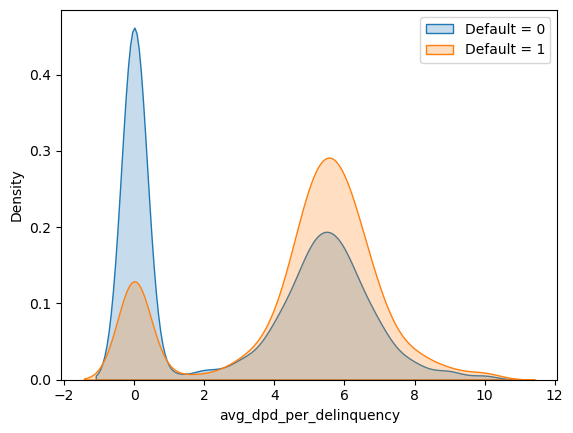

In [191]:
sns.kdeplot(df_train_1[df_train_1["default"] == 0].avg_dpd_per_delinquency,fill = True, label = "Default = 0")
sns.kdeplot(df_train_1[df_train_1["default"] == 1].avg_dpd_per_delinquency,fill = True, label = "Default = 1")
plt.legend()

In [192]:
df_test["avg_dpd_per_delinquency"] = np.where(df_test["delinquent_months"] != 0, 
                                                 df_test["total_dpd"]/df_test["delinquent_months"],0)

## Feature selection

In [193]:
df_train_1.drop(columns = {"cust_id","loan_id"},inplace = True)
df_test.drop(columns = {"cust_id","loan_id"},inplace = True)

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\1986751994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_1.drop(columns = {"cust_id","loan_id"},inplace = True)


In [194]:
# We can also remove sanction amount, and we can remove other columns that helped us create the above features like loan_amount and income

In [195]:
df_train_2 = df_train_1.drop(["disbursal_date","installment_start_dt","loan_amount","income","total_loan_months","delinquent_months","total_dpd"], axis = "columns")
df_test = df_test.drop(["disbursal_date","installment_start_dt","loan_amount","income","total_loan_months","delinquent_months","total_dpd"], axis = "columns")

In [196]:
df_train_2.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'Loan_to_income',
       'deliquent_to_loan_months', 'avg_dpd_per_delinquency'],
      dtype='object')

In [197]:
df_train_2.select_dtypes(include = [int,float]).columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'Loan_to_income',
       'deliquent_to_loan_months', 'avg_dpd_per_delinquency'],
      dtype='object')

In [198]:
X_train = df_train_2.drop(columns = "default")
y_train = df_train_2["default"]

In [199]:
cols_to_scale = X_train.select_dtypes(include = [int,float]).columns

In [200]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_purpose,loan_type,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,Loan_to_income,deliquent_to_loan_months,avg_dpd_per_delinquency
29671,0.40,M,Married,Salaried,0.60,Rented,0.27,Chennai,Tamil Nadu,0.83,Home,Secured,0.15,0.15,0.15,0.15,0.42,0.27,0.10,0.33,0.50,0.12,0.55,0.67,0.66,0.60
48133,0.37,M,Single,Salaried,0.00,Owned,0.87,Lucknow,Uttar Pradesh,0.20,Personal,Unsecured,0.02,0.02,0.02,0.02,0.23,0.15,0.09,1.00,1.00,0.38,0.00,0.15,0.00,0.00
2872,0.02,M,Single,Self-Employed,0.20,Owned,0.33,Chennai,Tamil Nadu,0.83,Home,Secured,0.08,0.07,0.07,0.07,0.42,0.09,0.07,1.00,0.00,1.00,0.43,0.82,0.01,0.40
23899,0.06,F,Single,Self-Employed,0.00,Owned,0.00,Pune,Maharashtra,0.51,Auto,Secured,0.03,0.02,0.02,0.02,0.40,0.07,0.04,0.67,0.50,0.38,0.60,0.23,0.27,0.57
40469,0.69,M,Single,Self-Employed,0.00,Owned,0.27,Lucknow,Uttar Pradesh,0.20,Home,Secured,0.11,0.11,0.11,0.11,0.53,0.32,0.07,1.00,0.00,0.88,0.15,0.55,0.10,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,0.52,F,Married,Salaried,0.60,Rented,0.93,Ahmedabad,Gujarat,0.46,Home,Secured,0.01,0.01,0.01,0.01,0.72,0.03,0.01,0.67,1.00,0.25,0.10,0.65,0.06,0.61
8006,0.44,F,Single,Self-Employed,0.00,Mortgage,0.13,Ahmedabad,Gujarat,0.46,Personal,Unsecured,0.10,0.08,0.08,0.08,0.06,0.57,0.40,1.00,0.00,0.50,0.05,0.10,0.00,0.00
17745,0.21,M,Married,Self-Employed,0.80,Owned,0.97,Bangalore,Karnataka,0.76,Personal,Unsecured,0.06,0.05,0.05,0.05,0.25,0.35,0.15,0.67,0.50,0.25,0.80,0.16,0.00,0.00
17931,0.40,M,Married,Self-Employed,0.40,Owned,0.87,Chennai,Tamil Nadu,0.83,Home,Secured,0.12,0.10,0.10,0.10,0.40,0.22,0.09,1.00,0.00,0.88,0.17,0.55,0.00,0.00


In [201]:
X_train[cols_to_scale]

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,Loan_to_income,deliquent_to_loan_months,avg_dpd_per_delinquency
29671,0.40,0.60,0.27,0.83,0.15,0.15,0.15,0.15,0.42,0.27,0.10,0.33,0.50,0.12,0.55,0.67,0.66,0.60
48133,0.37,0.00,0.87,0.20,0.02,0.02,0.02,0.02,0.23,0.15,0.09,1.00,1.00,0.38,0.00,0.15,0.00,0.00
2872,0.02,0.20,0.33,0.83,0.08,0.07,0.07,0.07,0.42,0.09,0.07,1.00,0.00,1.00,0.43,0.82,0.01,0.40
23899,0.06,0.00,0.00,0.51,0.03,0.02,0.02,0.02,0.40,0.07,0.04,0.67,0.50,0.38,0.60,0.23,0.27,0.57
40469,0.69,0.00,0.27,0.20,0.11,0.11,0.11,0.11,0.53,0.32,0.07,1.00,0.00,0.88,0.15,0.55,0.10,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,0.52,0.60,0.93,0.46,0.01,0.01,0.01,0.01,0.72,0.03,0.01,0.67,1.00,0.25,0.10,0.65,0.06,0.61
8006,0.44,0.00,0.13,0.46,0.10,0.08,0.08,0.08,0.06,0.57,0.40,1.00,0.00,0.50,0.05,0.10,0.00,0.00
17745,0.21,0.80,0.97,0.76,0.06,0.05,0.05,0.05,0.25,0.35,0.15,0.67,0.50,0.25,0.80,0.16,0.00,0.00
17931,0.40,0.40,0.87,0.83,0.12,0.10,0.10,0.10,0.40,0.22,0.09,1.00,0.00,0.88,0.17,0.55,0.00,0.00


In [202]:
X_test = df_test.drop(columns = "default")
y_test = df_test["default"]

In [203]:
# Do the same method for test
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test
# NOTE: We only do transform here since the scaler has already been fit to the data in the train and this is to avoid data leakage

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_purpose,loan_type,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,Loan_to_income,deliquent_to_loan_months,avg_dpd_per_delinquency
18447,0.52,F,Single,Self-Employed,0.00,Owned,0.80,Mumbai,Maharashtra,0.49,Personal,Unsecured,0.01,0.01,0.01,0.01,0.04,0.09,0.05,0.67,0.00,0.25,1.00,0.16,0.00,0.00
17768,0.15,M,Single,Self-Employed,0.00,Owned,0.30,Hyderabad,Telangana,0.66,Auto,Secured,0.06,0.05,0.05,0.05,0.43,0.17,0.13,0.00,0.00,0.50,0.48,0.24,0.20,0.45
45879,0.79,F,Married,Salaried,0.40,Owned,0.80,Mumbai,Maharashtra,0.49,Home,Secured,0.07,0.07,0.07,0.07,0.45,0.19,0.06,0.67,0.50,0.88,0.33,0.51,0.19,0.58
16972,0.48,F,Single,Self-Employed,0.00,Mortgage,0.47,Bangalore,Karnataka,0.76,Home,Secured,0.01,0.01,0.01,0.01,0.43,0.02,0.01,0.33,0.50,0.62,0.20,0.60,0.32,0.68
12165,0.54,M,Married,Self-Employed,0.60,Owned,0.47,Chennai,Tamil Nadu,0.83,Education,Secured,0.01,0.01,0.01,0.01,0.45,0.05,0.01,0.33,0.50,0.12,0.53,0.28,0.02,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22988,0.25,F,Married,Salaried,0.60,Owned,0.27,Hyderabad,Telangana,0.66,Auto,Secured,0.10,0.10,0.10,0.10,0.34,0.42,0.16,1.00,1.00,0.88,0.62,0.30,0.18,0.53
16478,0.63,M,Married,Salaried,0.40,Mortgage,0.20,Bangalore,Karnataka,0.76,Personal,Unsecured,0.01,0.01,0.01,0.01,0.19,0.04,0.02,0.33,1.00,0.50,0.42,0.12,0.08,0.44
26928,0.42,F,Married,Salaried,0.40,Owned,0.43,Jaipur,Rajasthan,0.33,Home,Secured,0.13,0.12,0.12,0.12,0.64,0.20,0.08,0.67,0.00,0.38,0.27,0.69,0.00,0.00
2922,0.38,F,Single,Salaried,0.20,Rented,0.43,Jaipur,Rajasthan,0.33,Home,Secured,0.06,0.05,0.05,0.05,0.42,0.09,0.03,0.00,0.50,0.38,0.90,0.61,0.15,0.72


In [204]:
## Using variance inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [205]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["variable"] = data.columns
    vif_df["VIF_Value"] = [variance_inflation_factor(data.values, i) for i in range (data.shape[1])]  
    # iterating through each column for that to be considered during VIF calc
    return vif_df

In [206]:
calculate_vif(X_train[cols_to_scale]) # Can only perform VIF on numeric cols

C:\Users\shreyas.sridharan.lv\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF_Value
0,age,5.70
1,number_of_dependants,2.72
2,years_at_current_address,3.45
3,zipcode,3.87
4,sanction_amount,102.67
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.19
9,principal_outstanding,16.57


In [207]:
## We need to drop the inf VIFs (all of them contribute to the overall loan amount etc so its obvuosult high0
# We also need to drop principal_outstanding and sanction_amount

In [208]:
X_train_1 = X_train.drop(columns = {"processing_fee","gst","net_disbursement","principal_outstanding","sanction_amount"})
X_train_1

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,loan_purpose,loan_type,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,Loan_to_income,deliquent_to_loan_months,avg_dpd_per_delinquency
29671,0.40,M,Married,Salaried,0.60,Rented,0.27,Chennai,Tamil Nadu,0.83,Home,Secured,0.42,0.10,0.33,0.50,0.12,0.55,0.67,0.66,0.60
48133,0.37,M,Single,Salaried,0.00,Owned,0.87,Lucknow,Uttar Pradesh,0.20,Personal,Unsecured,0.23,0.09,1.00,1.00,0.38,0.00,0.15,0.00,0.00
2872,0.02,M,Single,Self-Employed,0.20,Owned,0.33,Chennai,Tamil Nadu,0.83,Home,Secured,0.42,0.07,1.00,0.00,1.00,0.43,0.82,0.01,0.40
23899,0.06,F,Single,Self-Employed,0.00,Owned,0.00,Pune,Maharashtra,0.51,Auto,Secured,0.40,0.04,0.67,0.50,0.38,0.60,0.23,0.27,0.57
40469,0.69,M,Single,Self-Employed,0.00,Owned,0.27,Lucknow,Uttar Pradesh,0.20,Home,Secured,0.53,0.07,1.00,0.00,0.88,0.15,0.55,0.10,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5695,0.52,F,Married,Salaried,0.60,Rented,0.93,Ahmedabad,Gujarat,0.46,Home,Secured,0.72,0.01,0.67,1.00,0.25,0.10,0.65,0.06,0.61
8006,0.44,F,Single,Self-Employed,0.00,Mortgage,0.13,Ahmedabad,Gujarat,0.46,Personal,Unsecured,0.06,0.40,1.00,0.00,0.50,0.05,0.10,0.00,0.00
17745,0.21,M,Married,Self-Employed,0.80,Owned,0.97,Bangalore,Karnataka,0.76,Personal,Unsecured,0.25,0.15,0.67,0.50,0.25,0.80,0.16,0.00,0.00
17931,0.40,M,Married,Self-Employed,0.40,Owned,0.87,Chennai,Tamil Nadu,0.83,Home,Secured,0.40,0.09,1.00,0.00,0.88,0.17,0.55,0.00,0.00


In [214]:
vif_df = calculate_vif(X_train_1[X_train_1.select_dtypes(include = [int,float]).columns]) # Can only perform VIF on numeric cols
vif_df

,variable,VIF_Value
0,age,5.38
1,number_of_dependants,2.71
2,years_at_current_address,3.43
3,zipcode,3.83
4,loan_tenure_months,6.04
5,bank_balance_at_application,1.83
6,number_of_open_accounts,4.35
7,number_of_closed_accounts,2.37
8,enquiry_count,6.41
9,credit_utilization_ratio,2.93


In [220]:
selected_numeric_features_vif = vif_df.variable.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'Loan_to_income',
       'deliquent_to_loan_months', 'avg_dpd_per_delinquency'],
      dtype=object)

<Axes: >

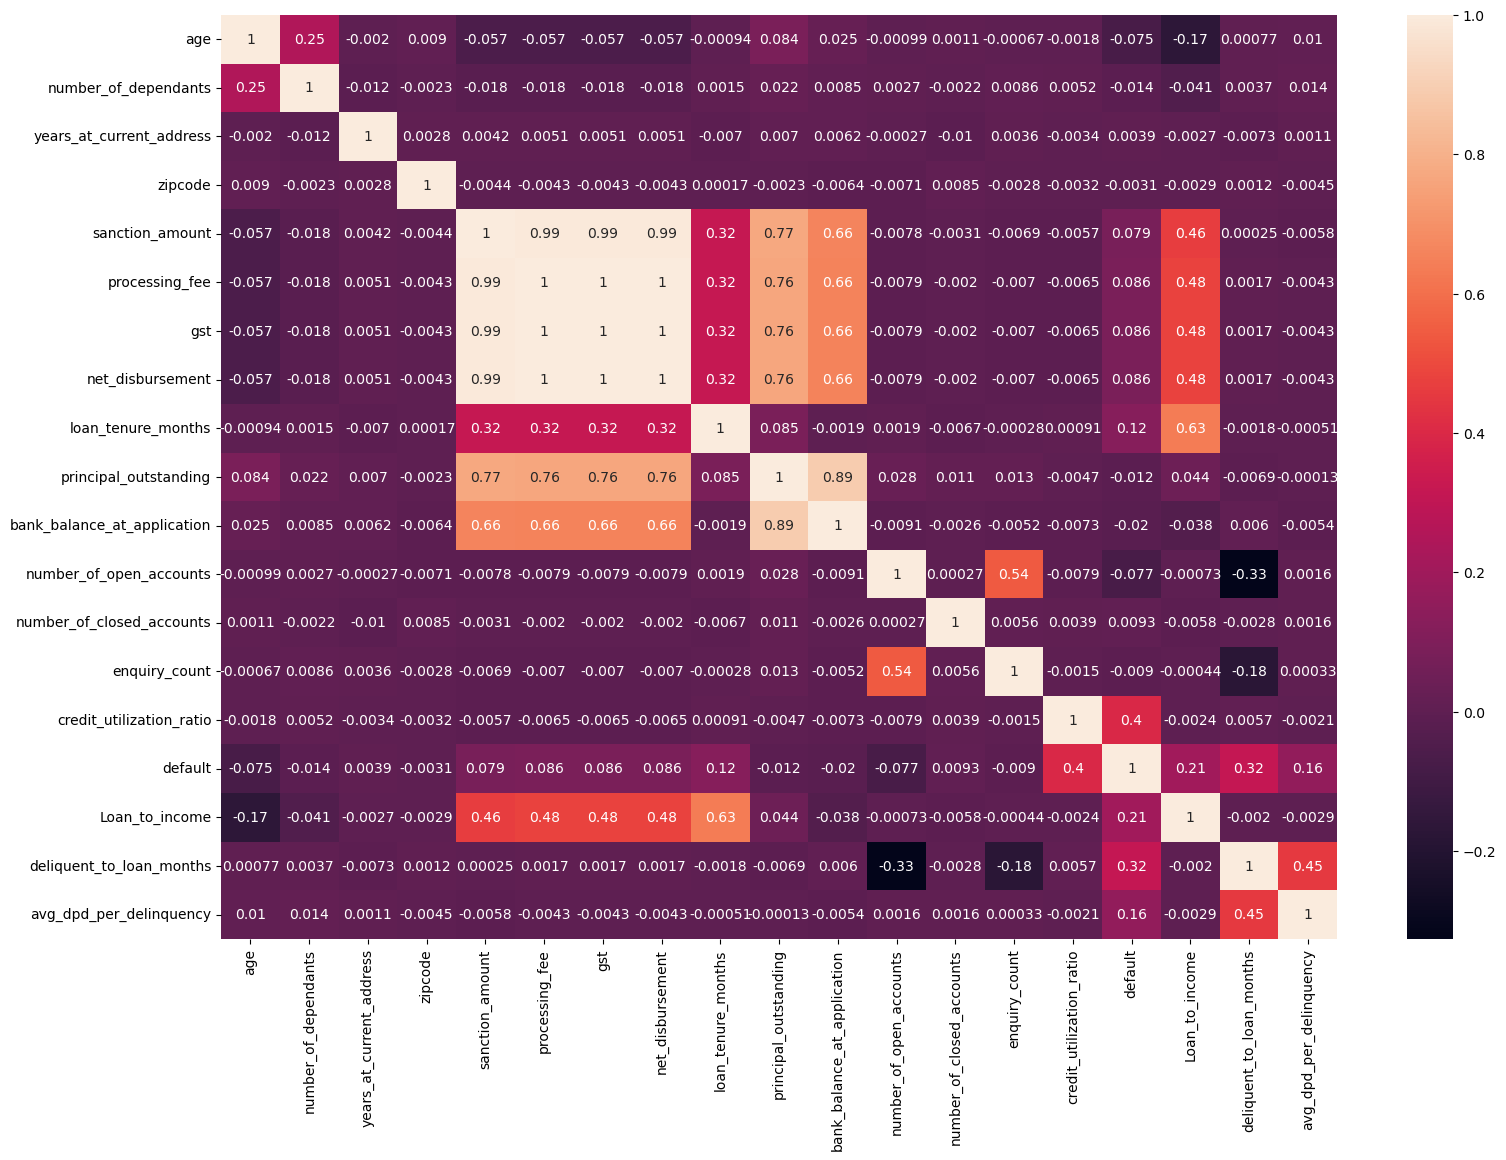

In [228]:
plt.figure(figsize = (18,12))
sns.heatmap(df_train_2[df_train_2.select_dtypes(include = [int,float]).columns].corr(), annot = True)

## Categorical columns (IMP BELOW)

Similar to how we used VIF, we are going to use <b>weight of evidence (WOE) and Information Value (IV) </b>
These are the two most famous method used in credit risk modelling to understand the infleucne of categorical features on a target variable

In [230]:
columns_cat = df_train_2.select_dtypes(include = [object]).columns
columns_cat

Index(['gender', 'marital_status', 'employment_status', 'residence_type',
       'city', 'state', 'loan_purpose', 'loan_type'],
      dtype='object')

In [232]:
df_train_2.groupby(["loan_purpose","default"])["default"].count()

loan_purpose  default
Auto          0           6659
              1            290
Education     0           4773
              1            536
Home          0           8874
              1           1648
Personal      0          11660
              1            555
Name: default, dtype: int64

In [236]:
for i in columns_cat:
    print(df_train_2.groupby([i,"default"])["default"].count())
    print("--------------------------------------")

gender  default
F       0          12825
        1           1228
M       0          19141
        1           1801
Name: default, dtype: int64
--------------------------------------
marital_status  default
Married         0          17573
                1           1566
Single          0          14393
                1           1463
Name: default, dtype: int64
--------------------------------------
employment_status  default
Salaried           0          11301
                   1           1140
Self-Employed      0          20665
                   1           1889
Name: default, dtype: int64
--------------------------------------
residence_type  default
Mortgage        0           7472
                1            779
Owned           0          18747
                1           1100
Rented          0           5747
                1           1150
Name: default, dtype: int64
--------------------------------------
city       default
Ahmedabad  0          3234
           1         

In [239]:
def calculate_voe_iv(df,feature,target):
    grouped = df.groupby([feature])[target].agg(['count','sum'])  ## here sum basically adds all the 1 values (basically countra ll defaults)
    grouped = grouped.rename(columns = {'count':'total','sum':'good'})
    grouped['bad'] = grouped['total'] - grouped['good']

    total_good = grouped['good'].sum()  # here default= 1 is good
    total_bad = grouped['bad'].sum() # here default = 0 is bad

    grouped["propotion good"] = grouped["good"]/total_good
    grouped["propotion bad"] = grouped["bad"]/total_bad

    grouped["WOE"] = np.log(grouped["propotion good"]/grouped["propotion bad"])
    grouped["WOE"] = grouped["WOE"].replace([np.inf,-np.inf],0)
    grouped["IV"] = grouped["WOE"]*(grouped["propotion good"] - grouped["propotion bad"])
    grouped["IV"] = grouped["IV"].replace([np.inf,-np.inf],0)

    Total_IV = grouped["IV"].sum()
    
    return grouped,Total_IV



grouped, total_iv = calculate_voe_iv(pd.concat([X_train_1,y_train], axis = 1),'loan_purpose','default')

In [245]:
print(total_iv)
grouped

## So a pretty strong IV value for loan_purpose

0.39649724078994064


,total,good,bad,propotion good,propotion bad,WOE,IV
loan_purpose,,,,,,,
Auto,6949,290,6659,0.10,0.21,-0.78,0.09
Education,5309,536,4773,0.18,0.15,0.17,0.00
Home,10522,1648,8874,0.54,0.28,0.67,0.18
Personal,12215,555,11660,0.18,0.36,-0.69,0.12


In [ ]:
columns_

In [263]:
iv_values = {}

for i in columns_cat:
    print(f"IV Score classification for {i}")
    grouped,total_iv = calculate_voe_iv(pd.concat([X_train_1,y_train], axis = 1),i,'default')
    print(grouped)
    print(f"Total IV Score for {i} is {total_iv}")
    print("---------------------------------")

    iv_values[i] = total_iv

IV Score classification for gender
        total  good    bad  propotion good  propotion bad   WOE   IV
gender                                                              
F       14053  1228  12825            0.41           0.40  0.01 0.00
M       20942  1801  19141            0.59           0.60 -0.01 0.00
Total IV Score for gender is 7.35390018707748e-05
---------------------------------
IV Score classification for marital_status
                total  good    bad  propotion good  propotion bad   WOE   IV
marital_status                                                              
Married         19139  1566  17573            0.52           0.55 -0.06 0.00
Single          15856  1463  14393            0.48           0.45  0.07 0.00
Total IV Score for marital_status is 0.004307873391000418
---------------------------------
IV Score classification for employment_status
                   total  good    bad  propotion good  propotion bad   WOE  \
employment_status                     

In [268]:
list(iv_values.items())

[('gender', np.float64(7.35390018707748e-05)),
 ('marital_status', np.float64(0.004307873391000418)),
 ('employment_status', np.float64(0.002249456407792333)),
 ('residence_type', np.float64(0.25868166303815804)),
 ('city', np.float64(0.001806802336136496)),
 ('state', np.float64(0.0018015307148026775)),
 ('loan_purpose', np.float64(0.39649724078994064)),
 ('loan_type', np.float64(0.1706183660230745))]

In [270]:
pd.DataFrame(list(iv_values.items()), columns = ['feature','iv_value'])

,feature,iv_value
0,gender,0.00
1,marital_status,0.00
2,employment_status,0.00
3,residence_type,0.26
4,city,0.00
5,state,0.00
6,loan_purpose,0.40
7,loan_type,0.17


Even those they are for cateogircal columns, we can bin numerical feature and still find IV VALUES

In [273]:
pd.cut(X_train_1["Loan_to_income"],bins = 10)

29671       (0.6, 0.7]
48133       (0.1, 0.2]
2872        (0.8, 0.9]
23899       (0.2, 0.3]
40469       (0.5, 0.6]
             ...      
5695        (0.6, 0.7]
8006     (-0.001, 0.1]
17745       (0.1, 0.2]
17931       (0.5, 0.6]
45919       (0.1, 0.2]
Name: Loan_to_income, Length: 34995, dtype: category
Categories (10, interval[float64, right]): [(-0.001, 0.1] < (0.1, 0.2] < (0.2, 0.3] < (0.3, 0.4] ... (0.6, 0.7] < (0.7, 0.8] < (0.8, 0.9] < (0.9, 1.0]]

In [276]:
iv_values = {}

for i in X_train_1.columns:
    if X_train_1[i].dtype == "object":
        print(f"IV Score classification for {i}")
        grouped,total_iv = calculate_voe_iv(pd.concat([X_train_1,y_train], axis = 1),i,'default')
        print(grouped)
        print(f"Total IV Score for {i} is {total_iv}")
        print("---------------------------------")
    else:
        X_binned = pd.cut(X_train_1[i], bins = 10, labels = False)
        grouped,total_iv = calculate_voe_iv(pd.concat([X_binned,y_train], axis = 1),i,'default')


    iv_values[i] = total_iv

IV Score classification for gender
        total  good    bad  propotion good  propotion bad   WOE   IV
gender                                                              
F       14053  1228  12825            0.41           0.40  0.01 0.00
M       20942  1801  19141            0.59           0.60 -0.01 0.00
Total IV Score for gender is 7.35390018707748e-05
---------------------------------
IV Score classification for marital_status
                total  good    bad  propotion good  propotion bad   WOE   IV
marital_status                                                              
Married         19139  1566  17573            0.52           0.55 -0.06 0.00
Single          15856  1463  14393            0.48           0.45  0.07 0.00
Total IV Score for marital_status is 0.004307873391000418
---------------------------------
IV Score classification for employment_status
                   total  good    bad  propotion good  propotion bad   WOE  \
employment_status                     

C:\Users\shreyas.sridharan.lv\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [282]:
pd.set_option("display.float_format",lambda x: '{:.3f}'.format(x))

iv_values_df = pd.DataFrame(list(iv_values.items()), columns = ["feature","iv_score"])
iv_values_df.sort_values(by = "iv_score",ascending = False)

,feature,iv_score
17,credit_utilization_ratio,2.360
19,deliquent_to_loan_months,0.717
18,Loan_to_income,0.501
10,loan_purpose,0.396
20,avg_dpd_per_delinquency,0.389
5,residence_type,0.259
12,loan_tenure_months,0.223
11,loan_type,0.171
14,number_of_open_accounts,0.088
0,age,0.085


In [283]:
## If IV is less than 0.02, we wont consider it

selected_features_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_features_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'Loan_to_income',
 'deliquent_to_loan_months',
 'avg_dpd_per_delinquency']

### Feature Encoding

In [284]:
X_train_reduced = X_train_1[selected_features_iv]
X_test = X_test[selected_features_iv]

In [286]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first = True)
X_test_encoded = pd.get_dummies(X_test, drop_first = True)

## Model Training and Fine Tuning

#### Attempt 1 - Without Class Imbalance

Lets try using Logistic Regression first since it has much better explainabilty when it comes to the impact of features on the model output.

In [289]:
from sklearn.linear_model import LogisticRegression

In [290]:
log_model = LogisticRegression()

In [292]:
log_model.fit(X_train_encoded,y_train)
y_pred = log_model.predict(X_test_encoded)

In [293]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     13730
           1       0.82      0.71      0.76      1268

    accuracy                           0.96     14998
   macro avg       0.90      0.85      0.87     14998
weighted avg       0.96      0.96      0.96     14998



In [294]:
# Here we care moer about recall since recall catches Fales negatives
# We dont want to have FN since falsely predicting a defaulter as non defaulter can be harmful

In [296]:
# Lets just try different classifiers
from sklearn.ensemble import RandomForestClassifier
random_model = RandomForestClassifier()
random_model.fit(X_train_encoded,y_train)
y_pred = random_model.predict(X_test_encoded)

print(classification_report(y_test,y_pred))

# A slight improvement in recall for class 1 but not significant (need above 90 for both classes)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     13730
           1       0.82      0.74      0.78      1268

    accuracy                           0.96     14998
   macro avg       0.90      0.86      0.88     14998
weighted avg       0.96      0.96      0.96     14998



In [297]:
from xgboost import XGBClassifier
random_model = XGBClassifier()
random_model.fit(X_train_encoded,y_train)
y_pred = random_model.predict(X_test_encoded)

print(classification_report(y_test,y_pred))

## Again no improvements

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     13730
           1       0.79      0.78      0.78      1268

    accuracy                           0.96     14998
   macro avg       0.88      0.88      0.88     14998
weighted avg       0.96      0.96      0.96     14998



In [309]:
## Lets try using randomized search CV for logistic regression

param_grid = {
    "C": np.linspace(0,10,20),
    'solver':['lbfgs','saga','liblinear','newton-cg']  # Algo to use in the optimization problem

}

log_reg = LogisticRegression(max_iter = 10000)


random_model = RandomizedSearchCV(log_reg, 
                                  param_distributions=param_grid,
                                  n_iter = 50,
                                  scoring = "recall",
                                  cv = 5,
                                  random_state = 101)

random_model.fit(X_train_encoded,y_train)

C:\Users\shreyas.sridharan.lv\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
15 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\shreyas.sridharan.lv\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shreyas.sridharan.lv\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\shreyas.sridharan.lv\anaconda3\Lib\site-

RandomizedSearchCV(cv=5, estimator=LogisticRegression(max_iter=10000),
                   n_iter=50,
                   param_distributions={'C': array([ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
        2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
        5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
        7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ]),
                                        'solver': ['lbfgs', 'saga', 'liblinear',
                                                   'newton-cg']},
                   random_state=101, scoring='recall')

In [310]:
print("Best Model:",random_model.best_estimator_)
print("Best Score:",random_model.best_score_)
print("Best params:",random_model.best_params_)

Best Model: LogisticRegression(C=np.float64(10.0), max_iter=10000, solver='newton-cg')
Best Score: 0.716740583149224
Best params: {'solver': 'newton-cg', 'C': np.float64(10.0)}


In [311]:
best_model = random_model.best_estimator_
best_model.fit(X_train_encoded,y_train)
y_pred = best_model.predict(X_test_encoded)

In [312]:
print(classification_report(y_test,y_pred))

# Scores are still the same

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     13730
           1       0.81      0.72      0.76      1268

    accuracy                           0.96     14998
   macro avg       0.89      0.85      0.87     14998
weighted avg       0.96      0.96      0.96     14998



#### Attempt 2 - Handling Class imbalance using under sampling

In [316]:
y_train.value_counts()

default
0    31966
1     3029
Name: count, dtype: int64

In [317]:
from imblearn.under_sampling import RandomUnderSampler
UnderSampler = RandomUnderSampler(random_state = 42)
X_train_und, y_train_und = UnderSampler.fit_resample(X_train_encoded,y_train)
y_train_und.value_counts()

default
0    3029
1    3029
Name: count, dtype: int64

In [318]:
log_model.fit(X_train_und,y_train_und)
y_pred = log_model.predict(X_test_encoded)
print(classification_report(y_test,y_pred))

# So here we can see that the recall has improved signficantly for 1 class
# The prevision has suffered but thats okay

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     13730
           1       0.50      0.96      0.66      1268

    accuracy                           0.92     14998
   macro avg       0.75      0.94      0.80     14998
weighted avg       0.95      0.92      0.93     14998



#### Attempt 3 - Class imbalance using SMOTE Tomek

In [319]:
from imblearn.combine import SMOTETomek
Tomek = SMOTETomek(random_state = 42)

X_train_tom,y_train_tom = Tomek.fit_resample(X_train_encoded,y_train)
print(y_train_tom.value_counts())

default
1    31895
0    31895
Name: count, dtype: int64


In [320]:
log_model.fit(X_train_tom,y_train_tom)
y_pred = log_model.predict(X_test_encoded)
print(classification_report(y_test,y_pred))

## Here recall of 1 has improved and precision is just a bit better

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     13730
           1       0.55      0.95      0.69      1268

    accuracy                           0.93     14998
   macro avg       0.77      0.94      0.83     14998
weighted avg       0.96      0.93      0.94     14998



NOTE: The above is an important way to increase recall for the minoirty class as the number of dat points either increases upto the other calss or the other class' data points become equal to taht of the minority class

## Optuna

In [321]:
pip install Optuna


   ---------------------------------------- 0/4 [Mako]
   ---------------------------------------- 0/4 [Mako]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   -------------------- ------------------- 2/4 [alembic]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   ------------------------------ --------- 3/4 [Optuna]
   -------------------------

In [323]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer,f1_score

In [325]:
# lets define the function to be maximized
def objective(trial):

    param = {
    "C" :trial.suggest_float("C",1,5),  # since its continous, we can pass a range here
    "solver":trial.suggest_categorical("solver",['lbfgs', 'liblinear','sag', 'saga']),
    "tol":trial.suggest_float('tol',1e-6,1e-1,log = True),  # Lograthimically spaced values for toleerance
    "class_weight": trial.suggest_categorical('class_weight',[None,'balanced']),


    }
    
    model = LogisticRegression(**param,max_iter = 1000)

    f1_scorer = make_scorer(f1_score,average = "macro")  # we are interested in the macro score that we see in the classification report
    scores = cross_val_score(model,X_train_tom,y_train_tom,cv = 3, scoring = f1_scorer, n_jobs = -1)
    accuracy = np.mean(scores)
    return accuracy
    
study = optuna.create_study(direction = "maximize")
study.optimize(objective, n_trials = 50)

print("Best parameters",study.best_params)
print("Best cross-validation accuracy",study.best_value)

[I 2026-01-13 01:10:52,198] A new study created in memory with name: no-name-5e1fd481-ea4b-4788-b906-2622f151eaa0
[I 2026-01-13 01:10:54,837] Trial 0 finished with value: 0.9439254313327846 and parameters: {'C': 1.5727358123888941, 'solver': 'lbfgs', 'tol': 3.095062345843432e-05, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9439254313327846.
[I 2026-01-13 01:10:57,620] Trial 1 finished with value: 0.9442540361738226 and parameters: {'C': 2.4358093605104654, 'solver': 'liblinear', 'tol': 0.003393745654058383, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9442540361738226.
[I 2026-01-13 01:11:00,189] Trial 2 finished with value: 0.9433973958679299 and parameters: {'C': 4.302633764880094, 'solver': 'saga', 'tol': 0.08640526778943067, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9442540361738226.
[I 2026-01-13 01:11:03,697] Trial 3 finished with value: 0.9441306657697285 and parameters: {'C': 4.1276148224044835, 'solver': 'sag', 'tol': 2.14081482220

Best parameters {'C': 2.1789095312990225, 'solver': 'liblinear', 'tol': 2.6498526442168036e-06, 'class_weight': 'balanced'}
Best cross-validation accuracy 0.9442851626597447


In [329]:
best_model_log = LogisticRegression(**study.best_params)
best_model_log.fit(X_train_tom,y_train_tom)

LogisticRegression(C=2.1789095312990225, class_weight='balanced',
                   solver='liblinear', tol=2.6498526442168036e-06)

In [330]:
y_pred = best_model_log.predict(X_test_encoded)
print(classification_report(y_test,y_pred))

# Not much improvement

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     13730
           1       0.55      0.95      0.70      1268

    accuracy                           0.93     14998
   macro avg       0.77      0.94      0.83     14998
weighted avg       0.96      0.93      0.94     14998



#### Attempt 4 - Using XGbosot with Class Imbalance

In [331]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_tom, y_train_tom, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-01-13 01:40:27,858] A new study created in memory with name: no-name-720691d8-9f0b-483e-ae41-d5500eb3668d
[I 2026-01-13 01:40:31,207] Trial 0 finished with value: 0.9500306298941347 and parameters: {'lambda': 6.494394037158631, 'alpha': 2.9703502624717157, 'subsample': 0.8327459038243104, 'colsample_bytree': 0.6897401553581564, 'max_depth': 5, 'eta': 0.13836606678743474, 'gamma': 6.453329719694546, 'scale_pos_weight': 7.523496458620093, 'min_child_weight': 4, 'max_delta_step': 7}. Best is trial 0 with value: 0.9500306298941347.
[I 2026-01-13 01:40:34,320] Trial 1 finished with value: 0.8929147454589389 and parameters: {'lambda': 3.8799297638953942, 'alpha': 0.04331324760029109, 'subsample': 0.4056196863736693, 'colsample_bytree': 0.7129826846790059, 'max_depth': 3, 'eta': 0.04901545533134644, 'gamma': 6.820593540001325, 'scale_pos_weight': 7.135789231851793, 'min_child_weight': 4, 'max_delta_step': 6}. Best is trial 0 with value: 0.9500306298941347.
[I 2026-01-13 01:40:37,667] 

In [334]:
trial = study_xgb.best_trial
trial.value  # best trial F1 Score, this is not the final F1 score

0.9777199459362649

In [332]:
best_model_xgb = XGBClassifier(**study_xgb.best_params)
best_model_xgb.fit(X_train_tom,y_train_tom)

XGBClassifier(alpha=0.036512317438724004, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7901837656520705, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eta=0.24795897471162542, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.014111171946558976,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=0.20748806334978032,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=9, max_depth=9,
              max_leaves=None, min_child_weight=2, missing=nan,
              monotone_constraints=None, multi_strategy=None, ...)

In [333]:
## Evaluting model on the test set
y_pred = best_model_xgb.predict(X_test_encoded)
print(classification_report(y_test,y_pred))

# Slighlty better macro average F1 sccore

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     13730
           1       0.71      0.84      0.77      1268

    accuracy                           0.96     14998
   macro avg       0.85      0.90      0.87     14998
weighted avg       0.96      0.96      0.96     14998



But here, we still care more about recall, so we will go back to log model itself

In [337]:
y_pred = best_model_log.predict(X_test_encoded)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.93      0.96     13730
           1       0.55      0.95      0.70      1268

    accuracy                           0.93     14998
   macro avg       0.77      0.94      0.83     14998
weighted avg       0.96      0.93      0.94     14998



## Lets also try fidning AUC-ROC score

In [345]:
from sklearn.metrics import roc_curve

probabilities = best_model_log.predict_proba(X_test_encoded)
probabilities[:,1]  # we should only take the probabilties of +ve calss as the curve plts FPR vs TPR

array([1.31130978e-01, 8.02802150e-04, 7.55831952e-04, ...,
       2.63731612e-04, 9.96883285e-01, 2.73363336e-06])

In [347]:
fpr,tpr,thresholds = roc_curve(y_test,probabilities[:,1])

In [349]:
fpr[:10], tpr[:10], thresholds[:10]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.28332119e-05,
        7.28332119e-05, 1.45666424e-04, 1.45666424e-04, 2.18499636e-04,
        2.18499636e-04, 2.91332848e-04]),
 array([0.        , 0.00078864, 0.15063091, 0.15063091, 0.1522082 ,
        0.1522082 , 0.15378549, 0.15378549, 0.20031546, 0.20031546]),
 array([       inf, 0.99999985, 0.99908553, 0.99907747, 0.99907241,
        0.99900426, 0.99900035, 0.99899952, 0.99826965, 0.99825279]))

In [350]:
from sklearn.metrics import auc

area = auc(fpr,tpr)
area

np.float64(0.9839537750349806)

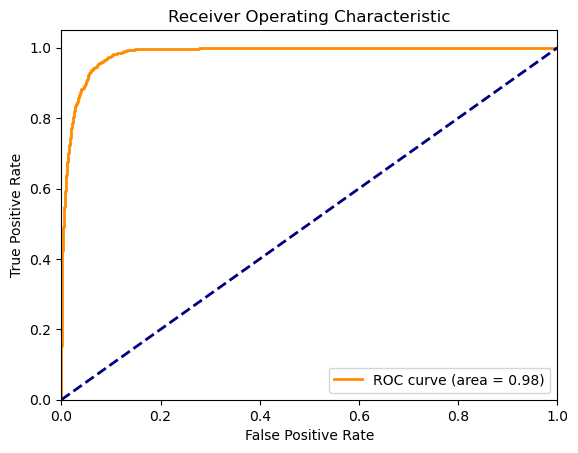

In [351]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Model Evalulation: Rankorder & KS Statistic

In [356]:
probabilities = best_model_log.predict_proba(X_test_encoded)[:,1]  # taking default prob alone

In [357]:
df_eval = pd.DataFrame({
    "Default Truth":y_test,
    "Default Probability":probabilities
})

In [362]:
df_eval.sort_values(by = "Default Probability", ascending = False).head(10)

,Default Truth,Default Probability
16684,1,1.000
48416,1,1.000
30535,1,1.000
15711,1,1.000
610,1,1.000
14495,1,1.000
3878,1,1.000
24091,1,1.000
21874,1,1.000
8124,1,1.000


In [363]:
## Creating declines
df_eval["deciles"] = pd.qcut(df_eval["Default Probability"],10,labels = False, duplicates = "drop")

# Higher values will be in a higher decile

In [366]:
df_grouped = df_eval.groupby(["deciles"]).apply(lambda x: pd.Series({
    "Minimum Probability": x["Default Probability"].min(),
    "Maximum Probability": x["Default Probability"].max(),
    "Events": x["Default Truth"].sum(),   # getting all defaulted values
    "Non-Events":x["Default Truth"].count() - x["Default Truth"].sum()
    
}))

C:\Users\shreyas.sridharan.lv\AppData\Local\Temp\ipykernel_31208\3012677459.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_grouped = df_eval.groupby(["deciles"]).apply(lambda x: pd.Series({


In [375]:
df_grouped["Event Rate"] = 100*df_grouped["Events"]/(df_grouped["Events"] + df_grouped["Non-Events"])
df_grouped["Non Event Rate"] = 100*df_grouped["Non-Events"]/(df_grouped["Events"] + df_grouped["Non-Events"])

In [376]:
df_grouped.sort_index(ascending = False, inplace = True)

In [377]:
df_grouped
# if we look at event_rate 71% of default cases in reality are captured in the highest decile so kinda gives an indication our mdoel is performing well

,Minimum Probability,Maximum Probability,Events,Non-Events,Event Rate,Non Event Rate
deciles,,,,,,
9,0.813,1.000,1070.000,430.000,71.333,28.667
8,0.228,0.813,187.000,1313.000,12.467,87.533
7,0.037,0.228,8.000,1492.000,0.533,99.467
6,0.007,0.037,3.000,1496.000,0.200,99.800
5,0.001,0.007,0.000,1500.000,0.000,100.000
4,0.000,0.001,0.000,1500.000,0.000,100.000
3,0.000,0.000,0.000,1499.000,0.000,100.000
2,0.000,0.000,0.000,1500.000,0.000,100.000
1,0.000,0.000,0.000,1500.000,0.000,100.000


In [378]:
df_grouped["Cum Events"] = df_grouped["Events"].cumsum()
df_grouped["Cum Non Events"] = df_grouped["Non-Events"].cumsum()

In [380]:
df_grouped.head()

,Minimum Probability,Maximum Probability,Events,Non-Events,Event Rate,Non Event Rate,Cum Events,Cum Non Events
deciles,,,,,,,,
9,0.813,1.000,1070.000,430.000,71.333,28.667,1070.000,430.000
8,0.228,0.813,187.000,1313.000,12.467,87.533,1257.000,1743.000
7,0.037,0.228,8.000,1492.000,0.533,99.467,1265.000,3235.000
6,0.007,0.037,3.000,1496.000,0.200,99.800,1268.000,4731.000
5,0.001,0.007,0.000,1500.000,0.000,100.000,1268.000,6231.000


In [385]:
## we also find the cumulative event and non event rate
df_grouped["Cum Event Rate"] = 100*df_grouped["Cum Events"]/sum(df_grouped["Events"])
df_grouped["Cum Non Event Rate"] = 100*df_grouped["Cum Non Events"]/sum(df_grouped["Non-Events"])

In [386]:
df_grouped

# So here we are able to capture over 90% of Default events within first two deciles itself
# This indicates the model is perofrming very well

,Minimum Probability,Maximum Probability,Events,Non-Events,Event Rate,Non Event Rate,Cum Events,Cum Non Events,Cum Event Rate,Cum Non Event Rate,KS Statistic
deciles,,,,,,,,,,,
9,0.813,1.000,1070.000,430.000,71.333,28.667,1070.000,430.000,84.385,3.132,0.813
8,0.228,0.813,187.000,1313.000,12.467,87.533,1257.000,1743.000,99.132,12.695,0.864
7,0.037,0.228,8.000,1492.000,0.533,99.467,1265.000,3235.000,99.763,23.562,0.762
6,0.007,0.037,3.000,1496.000,0.200,99.800,1268.000,4731.000,100.000,34.457,0.655
5,0.001,0.007,0.000,1500.000,0.000,100.000,1268.000,6231.000,100.000,45.382,0.546
4,0.000,0.001,0.000,1500.000,0.000,100.000,1268.000,7731.000,100.000,56.307,0.437
3,0.000,0.000,0.000,1499.000,0.000,100.000,1268.000,9230.000,100.000,67.225,0.328
2,0.000,0.000,0.000,1500.000,0.000,100.000,1268.000,10730.000,100.000,78.150,0.218
1,0.000,0.000,0.000,1500.000,0.000,100.000,1268.000,12230.000,100.000,89.075,0.109


In [387]:
# Lets also find the KS Statistic
df_grouped["KS Statistic"] = abs(df_grouped["Cum Event Rate"] - df_grouped["Cum Non Event Rate"])
df_grouped

,Minimum Probability,Maximum Probability,Events,Non-Events,Event Rate,Non Event Rate,Cum Events,Cum Non Events,Cum Event Rate,Cum Non Event Rate,KS Statistic
deciles,,,,,,,,,,,
9,0.813,1.000,1070.000,430.000,71.333,28.667,1070.000,430.000,84.385,3.132,81.253
8,0.228,0.813,187.000,1313.000,12.467,87.533,1257.000,1743.000,99.132,12.695,86.438
7,0.037,0.228,8.000,1492.000,0.533,99.467,1265.000,3235.000,99.763,23.562,76.202
6,0.007,0.037,3.000,1496.000,0.200,99.800,1268.000,4731.000,100.000,34.457,65.543
5,0.001,0.007,0.000,1500.000,0.000,100.000,1268.000,6231.000,100.000,45.382,54.618
4,0.000,0.001,0.000,1500.000,0.000,100.000,1268.000,7731.000,100.000,56.307,43.693
3,0.000,0.000,0.000,1499.000,0.000,100.000,1268.000,9230.000,100.000,67.225,32.775
2,0.000,0.000,0.000,1500.000,0.000,100.000,1268.000,10730.000,100.000,78.150,21.850
1,0.000,0.000,0.000,1500.000,0.000,100.000,1268.000,12230.000,100.000,89.075,10.925


1. So here the Max KS Value should be within the first 3 deciles and the value should be above 40%
2. Here it is 86.43 and it is within the top 3 deciles, idcating how well our model is performing

## Save the Model

In [398]:
final_model = best_model_log

feature_importance = final_model.coef_[0]

<Axes: ylabel='None'>

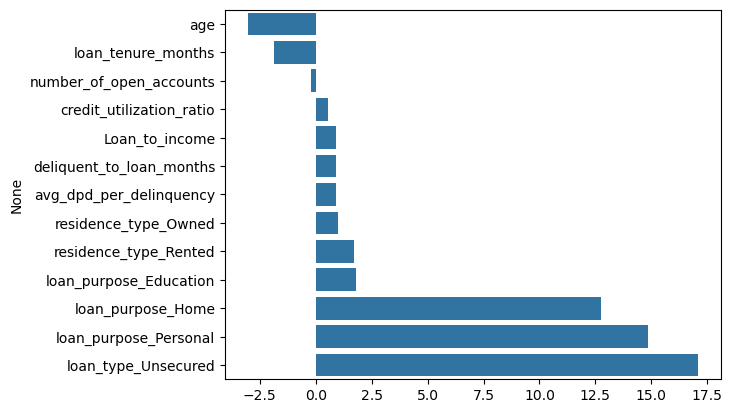

In [402]:
sns.barplot(y = X_test_encoded.columns,x = feature_importance)

In [403]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'Loan_to_income',
       'deliquent_to_loan_months', 'avg_dpd_per_delinquency',
       'residence_type_Owned', 'residence_type_Rented',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
       'loan_type_Unsecured'],
      dtype='object')

In [404]:
from joblib import dump

model_data = {
    'model':final_model,
    'features':X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale':cols_to_scale

}
dump(model_data,'artifacts/model_data.joblib')

['artifacts/model_data.joblib']